**Model Name: Breast Cancer Model📊**

------



# 🤖 Machine Learning Model Summary – Breast Cancer Classifier


🎯 **Model Objective:**  
Build a reliable ML model to classify breast tumors into **Benign (0)** or **Malignant (1)** based on diagnostic features.

🔍 **Modeling Approach:**
To achieve the highest accuracy with minimal overfitting, three different machine learning algorithms were trained and compared:

1️⃣ **Logistic Regression**  
2️⃣ **Decision Tree Classifier**  
3️⃣ **Random Forest Classifier**

4️⃣ Support Vector Machine (SVM)

🧪 **Evaluation Strategy:**  
• Train/Test split  
• Accuracy comparison  
• Classification reports  
• Confusion matrices  
• Overfitting check through train vs test accuracy  

📊 **Model Comparison Highlights:**  
• Logistic Regression → Best balance of accuracy & generalization  
• Decision Tree → Overfitted the training data  
• Random Forest → High accuracy but slight overfitting  

🏆 **Final Selected Model:**  
✔ **Logistic Regression**  
Chosen for: high accuracy, stability, interpretability, and excellent generalization performance.

📉 **Dimensionality Reduction (PCA):**  
Used PCA (2D & 3D) **only for visualization**, allowing clear separation between benign and malignant clusters.

🚀 **Model Usage:**  
The final Logistic Regression model was saved and integrated into a full **Streamlit web application** for real-time breast cancer prediction.

📁 **Model Status:** READY FOR DEPLOYMENT  



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold,cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve , auc
import pickle

##Load and Read the data

In [ ]:
data=pd.read_csv("/content/data (6).csv")
data

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

#Preprocessing


In [ ]:
data.drop(["id","Unnamed: 32"],axis=1,inplace=True)
data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
data.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [ ]:
data.isna().sum()

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


In [ ]:
#Duplicated of data
print(data.duplicated().sum())

0


In [ ]:
#Convert M--->1 and B--->0
data["diagnosis"] = [1 if value=="M" else 0 for value in data["diagnosis"]]
data["diagnosis"].value_counts()

,count
diagnosis,
0,357
1,212


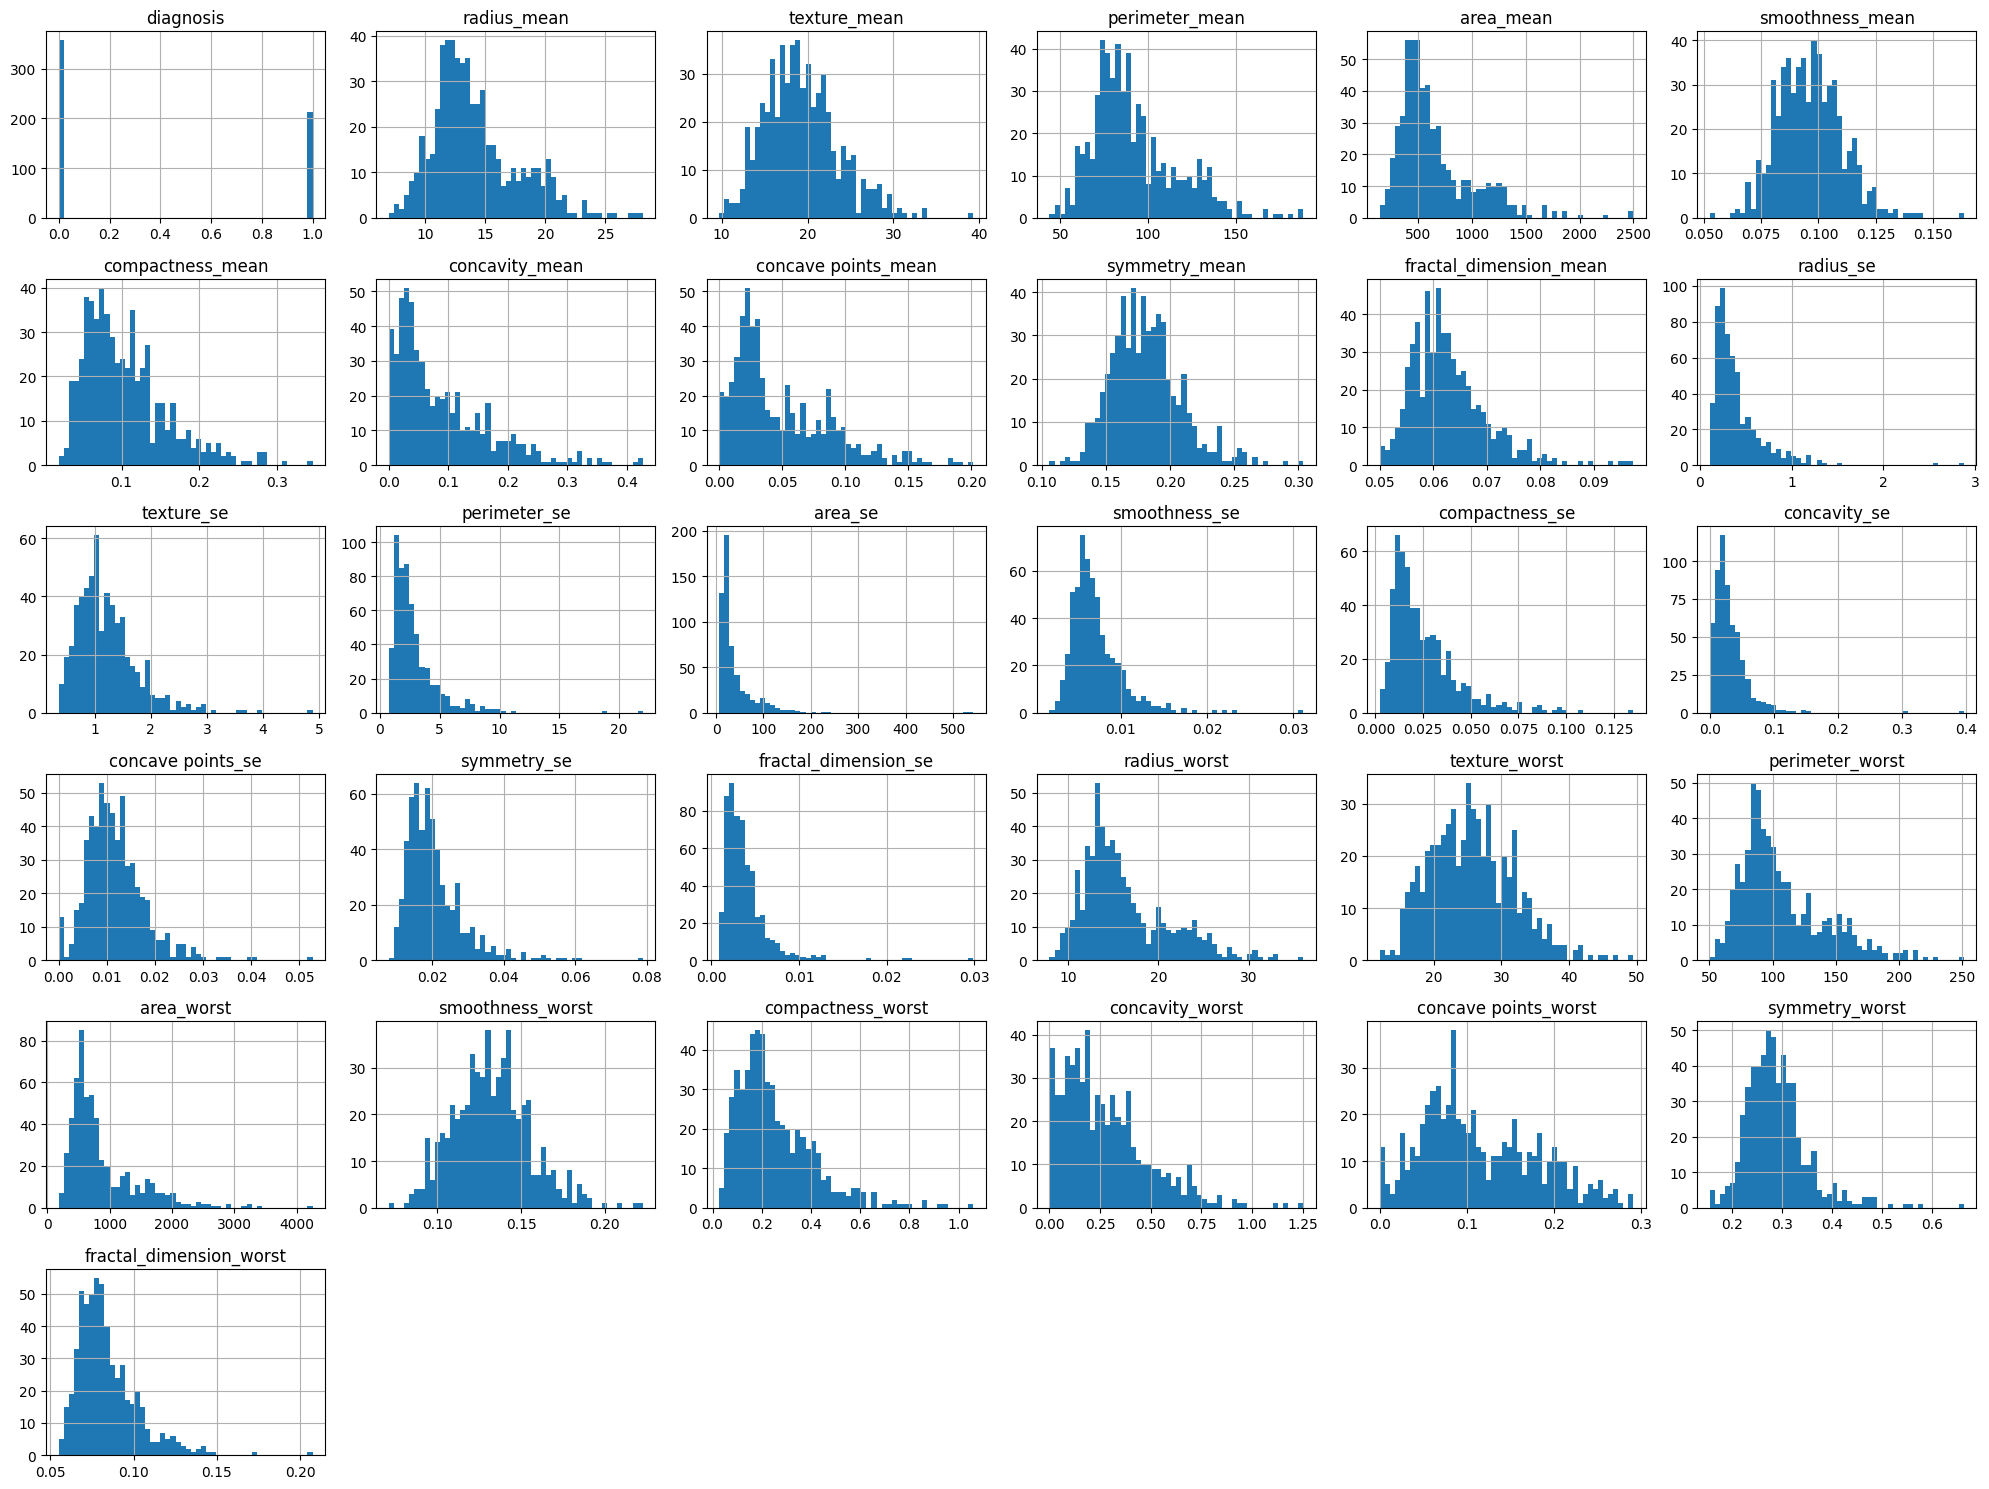

In [ ]:
#Histogram for all columns in data
data.hist(bins=50, figsize=(20, 15))
plt.tight_layout()
plt.show()


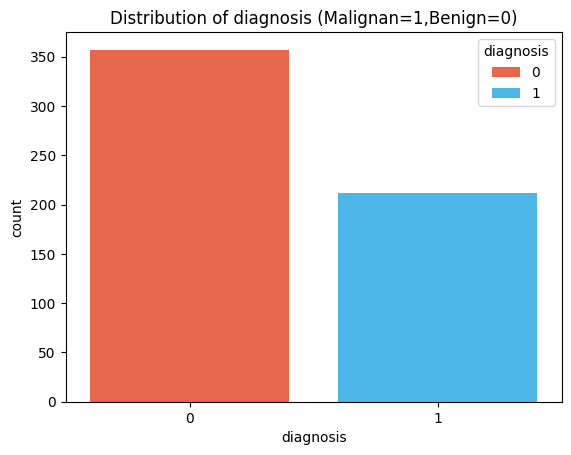

In [ ]:
sns.countplot(x=data["diagnosis"],data=data,hue="diagnosis",palette=["#FF5733", "#33C1FF"])
plt.title("Distribution of diagnosis (Malignan=1,Benign=0)")
plt.show()

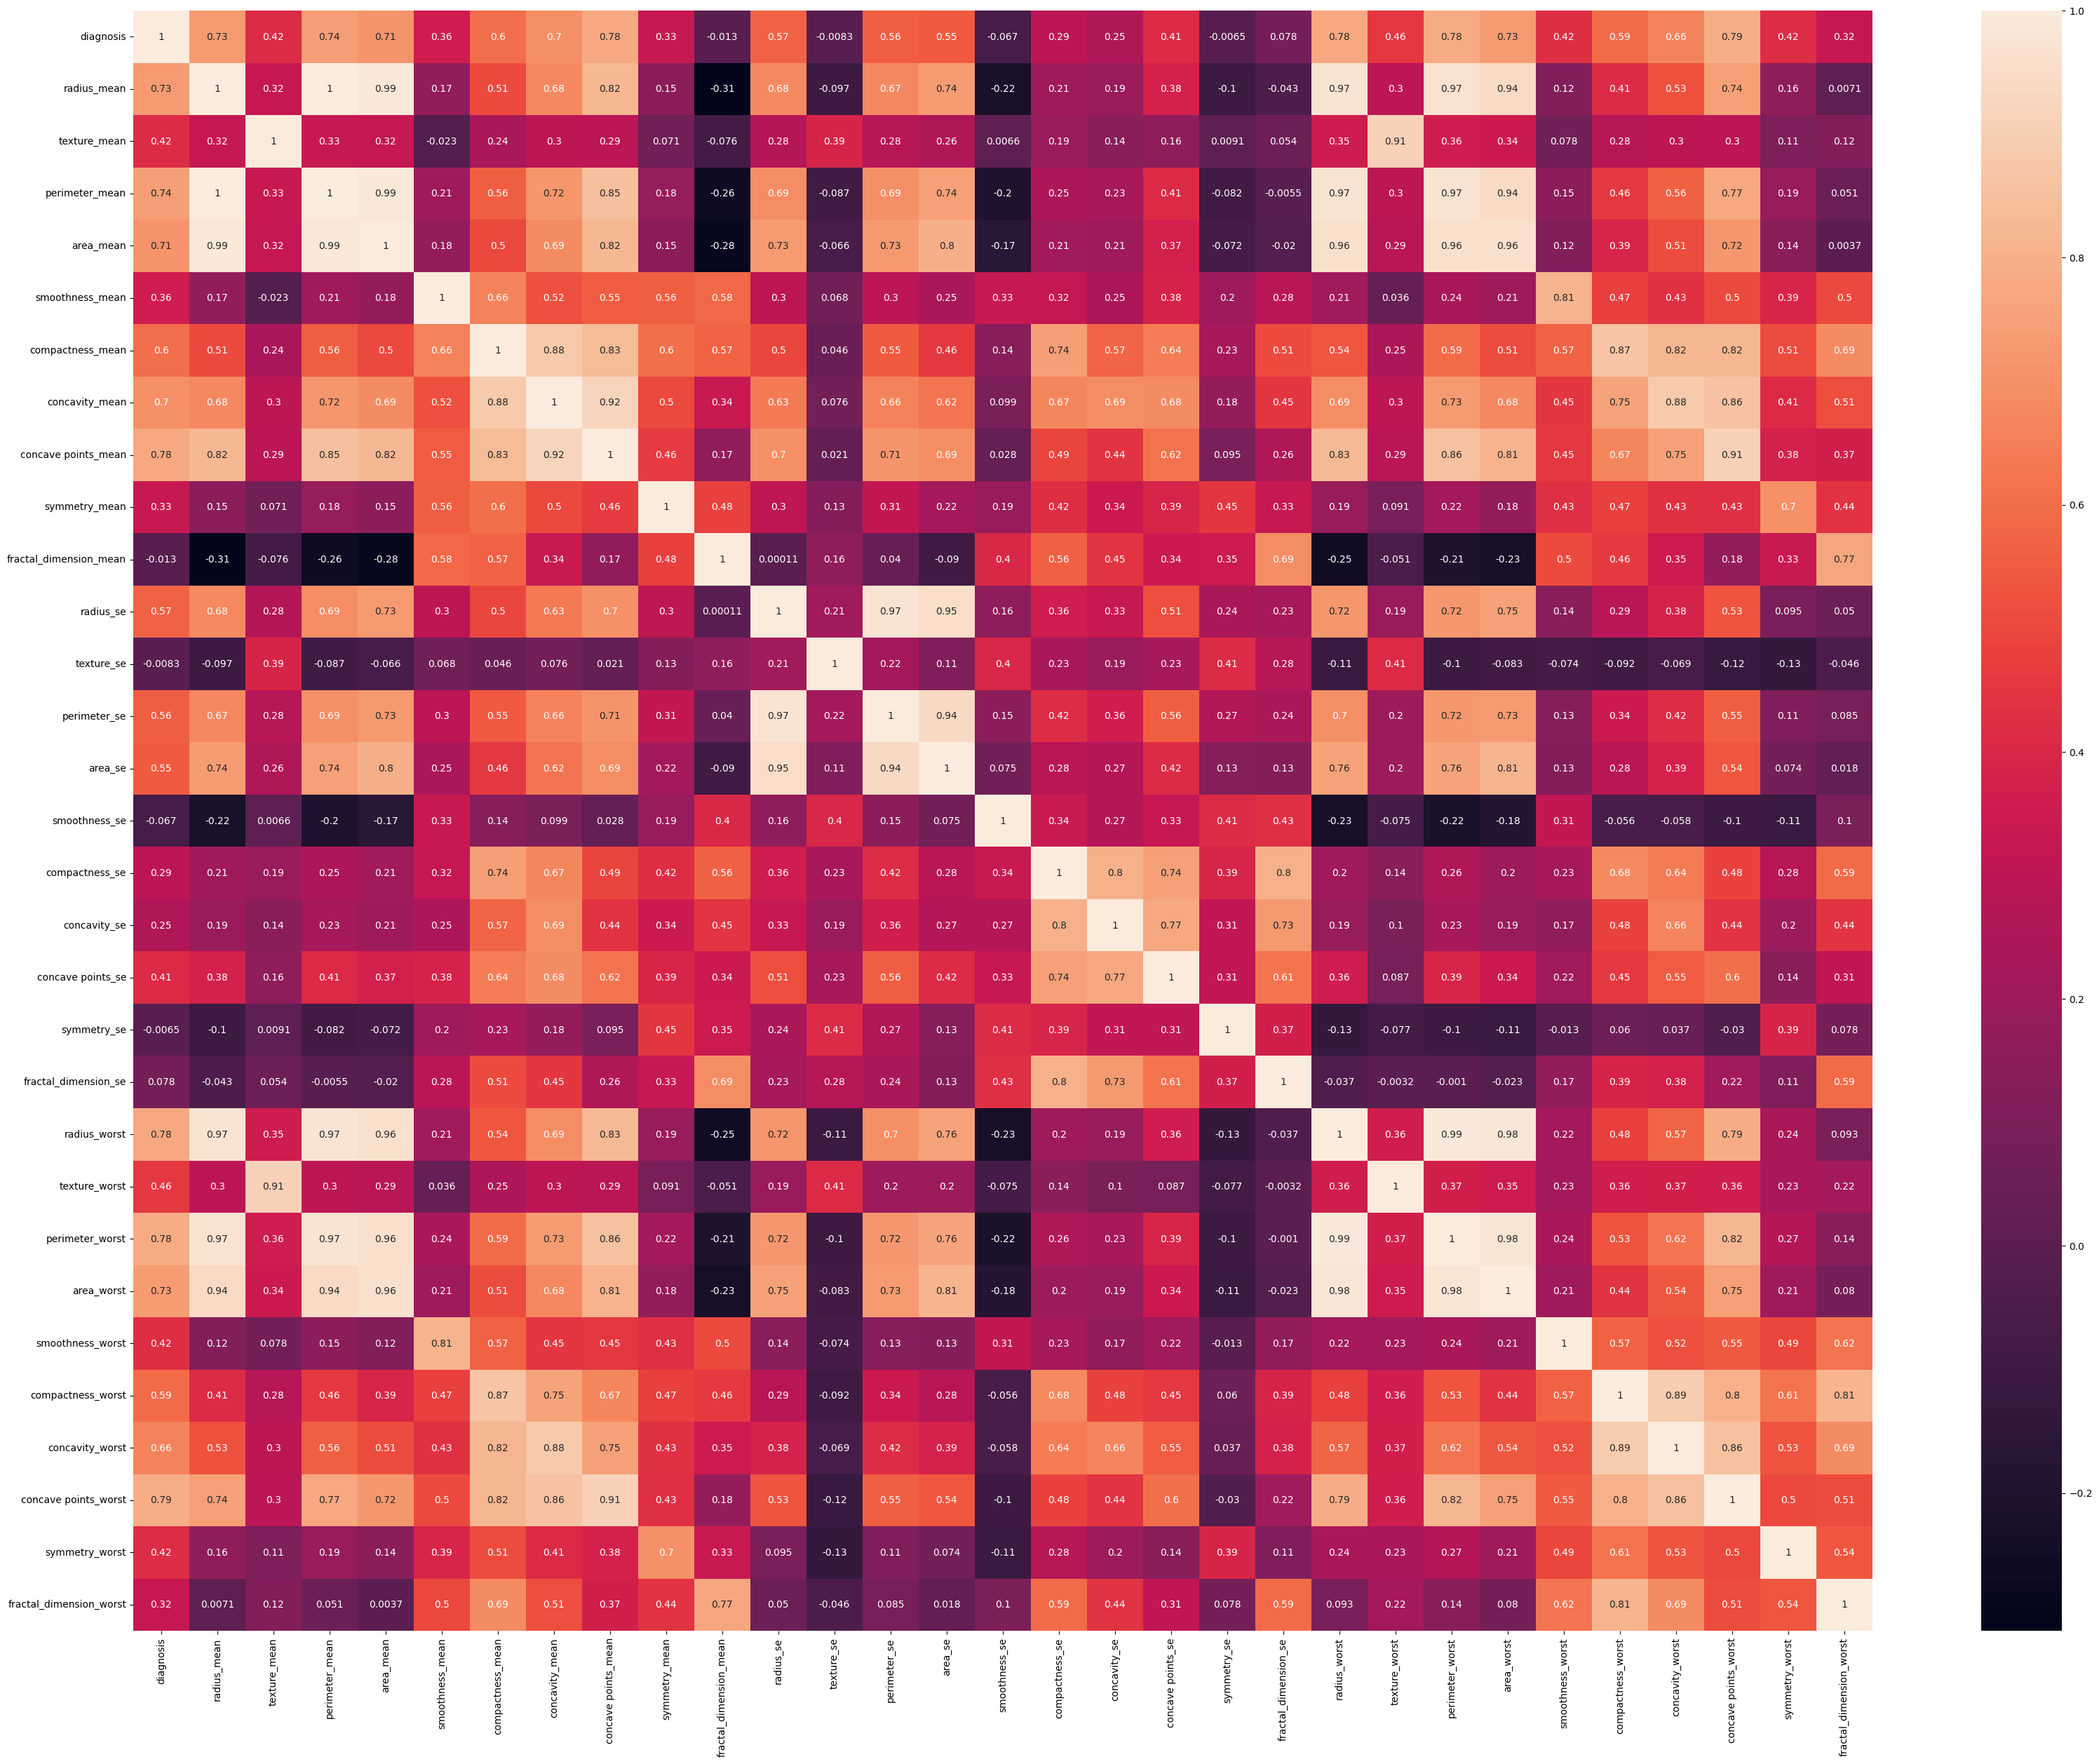

In [ ]:
# Heatmap showing correlations between features
plt.figure(figsize=(40,30))
sns.heatmap(data.corr(),annot=True)
plt.show()

In [ ]:
# Calculate correlations of all features with Target'diagnosis' and sort them
correlations = data.corr()['diagnosis'].sort_values(ascending=False)
correlations

,diagnosis
diagnosis,1.000000
concave points_worst,0.793566
perimeter_worst,0.782914
concave points_mean,0.776614
radius_worst,0.776454
perimeter_mean,0.742636
area_worst,0.733825
radius_mean,0.730029
area_mean,0.708984
concavity_mean,0.696360


In [ ]:
#Drop for columns with law corr with Target
data.drop(["symmetry_se","texture_se","fractal_dimension_mean","smoothness_se"],axis=1,inplace=True)

In [ ]:
#Determine the Features columns and Target column
X=data.drop(["diagnosis"],axis=1)
y=data["diagnosis"]

In [ ]:
# Apply StandardScaler to standardize features (mean=0, std=1)
scaler=StandardScaler()
data=scaler.fit_transform(x)

In [ ]:
X

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,radius_se,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,1.0950,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.5435,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.7456,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.4956,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.7572,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,1.1760,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.7655,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.4564,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.7260,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
#Split for data to X_train , X_test, y_train, y_test
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)
print(X_train.shape)
print(X_test.shape)

(398, 26)
(171, 26)


##LogisticRegression

In [ ]:
# Create Model
leg=LogisticRegression()

#Cross Validation

In [ ]:
#Cross Validation
# Perform 5fold cross validation to evaluate the model's performance on different subsets of the data
kf=KFold(n_splits=5,shuffle=True,random_state=42)
cross_score=cross_val_score(leg,X,y,cv=kf)
print(cross_score)

[0.96491228 0.98245614 0.9122807  0.97368421 0.91150442]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [ ]:
#Train MOdel
leg.fit(X_train,y_train)
#y prediction
y_pred=leg.predict(X_test)

In [ ]:
print(y_pred)

[0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 1 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 1 1 1 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1 1
 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0]


In [ ]:
# Check predicted vs actual label counts and overall accuracy
print(pd.Series(y_pred).value_counts())
print("-"*50)
print(pd.Series(y_test).value_counts())
print("-"*50)

# Show test accuracy by comparing predictions with actual labels
print("Accuracy: ",accuracy_score(y_test,y_pred))


0    107
1     64
Name: count, dtype: int64
--------------------------------------------------
diagnosis
0    108
1     63
Name: count, dtype: int64
--------------------------------------------------
Accuracy:  0.9824561403508771


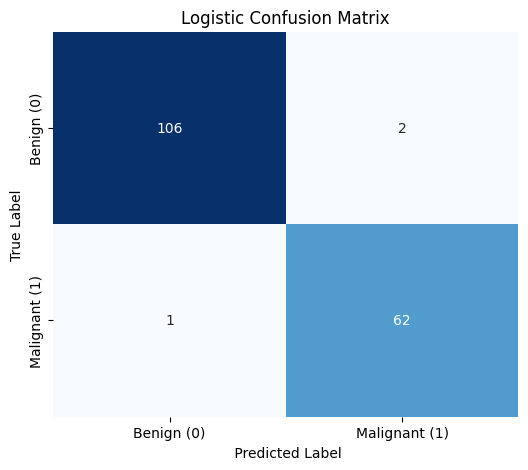

In [ ]:
# Show how well the model predicted each class
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])
plt.xlabel(' Predicted Label')
plt.ylabel('True Label')
plt.title('Logistic Confusion Matrix')
plt.show()

In [ ]:
# Show detailed metrics (precision, recall, f1-score) for each class
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       108
           1       0.97      0.95      0.96        63

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171



In [ ]:
# Calculate and print the training and testing accuracy of the model
train_acc = leg.score(X_train, y_train)
test_acc = leg.score(X_test, y_test)

print("train_accuracy:",train_acc,"\ntest_accuracy:" ,test_acc)

train_accuracy: 0.9472361809045227 
test_accuracy: 0.9707602339181286


## DecisionTreeClassifier


In [ ]:
# Create Decision Tree model
model = DecisionTreeClassifier(
    criterion='gini',           # "gini" for Gini impurity, "entropy" for information gain
    max_depth=6,             # max depth of the tree (None = unlimited)
    min_samples_split=2,        # min samples to split an internal node
    min_samples_leaf=1,         # min samples required at a leaf node
    max_features=None,          # max features to consider for a split
    random_state=42
)


In [ ]:
#Cross validation
cross_score=cross_val_score(model,X,y,cv=kf)
print(cross_score)

# Train the model
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

[0.92982456 0.95614035 0.92982456 0.94736842 0.94690265]


In [ ]:
# Show test accuracy by comparing predictions with actual labels
print(" Accuracy:", accuracy_score(y_test, y_pred))
print("-"*50)

# Print detailed classification metrics (precision, recall, f1-score) for each class
print("Classification report:\n", classification_report(y_test, y_pred))

 Accuracy: 0.9532163742690059
--------------------------------------------------
Classification report:
               precision    recall  f1-score   support

           0       0.97      0.95      0.96       108
           1       0.92      0.95      0.94        63

    accuracy                           0.95       171
   macro avg       0.95      0.95      0.95       171
weighted avg       0.95      0.95      0.95       171



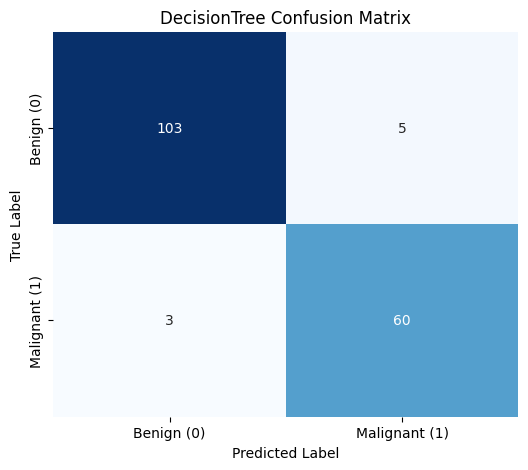

In [ ]:
# Show how well the model predicted each class
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('DecisionTree Confusion Matrix')
plt.show()

In [ ]:
# Calculate and print the training and testing accuracy of the model
train_acc =model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("train_accuracy:",train_acc,"\ntest_accuracy:" ,test_acc)

train_accuracy: 0.9974874371859297 
test_accuracy: 0.9532163742690059


## RandomForestClassifier


In [ ]:
# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,           # number of trees
    criterion='gini',           # splitting criterion
    max_depth=None,             # max depth of trees
    min_samples_split=2,        # min samples to split a node
    min_samples_leaf=1,         # min samples per leaf
    max_features='sqrt',        # updated: 'sqrt' instead of 'auto'
    bootstrap=True,             # use bootstrap samples
    random_state=42,            # reproducibility
    n_jobs=-1                   # use all CPU cores
)

In [ ]:
#Cross validation
cross_score=cross_val_score(rf_model,X,y,cv=kf)
print(cross_score)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred = rf_model.predict(X_test)

[0.96491228 0.98245614 0.92982456 0.97368421 0.95575221]


In [ ]:
# Show test accuracy by comparing predictions with actual labels
print(" Accuracy:", accuracy_score(y_test, y_pred))
print("-"*50)

# Print detailed classification metrics (precision, recall, f1-score) for each class
print("Classification report:\n", classification_report(y_test, y_pred))

 Accuracy: 0.9766081871345029
--------------------------------------------------
Classification report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       108
           1       0.98      0.95      0.97        63

    accuracy                           0.98       171
   macro avg       0.98      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



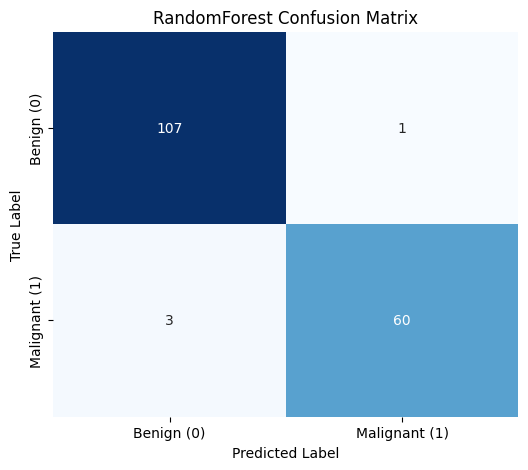

In [ ]:
# Show how well the model predicted each class
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('RandomForest Confusion Matrix')
plt.show()

In [ ]:
# Calculate and print the training and testing accuracy of the model
train_acc =rf_model.score(X_train, y_train)
test_acc = rf_model.score(X_test, y_test)

print("train_accuracy:",train_acc,"\ntest_accuracy:" ,test_acc)

train_accuracy: 1.0 
test_accuracy: 0.9766081871345029


#Support Vector Machine

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)


In [ ]:
#Cross validation
cross_score=cross_val_score(svm_model,X,y,cv=kf)
print(cross_score)

# Train the model
svm_model.fit(X_train, y_train)

# Predict on test set
y_pred = svm_model.predict(X_test)

[0.94736842 0.94736842 0.89473684 0.92982456 0.86725664]


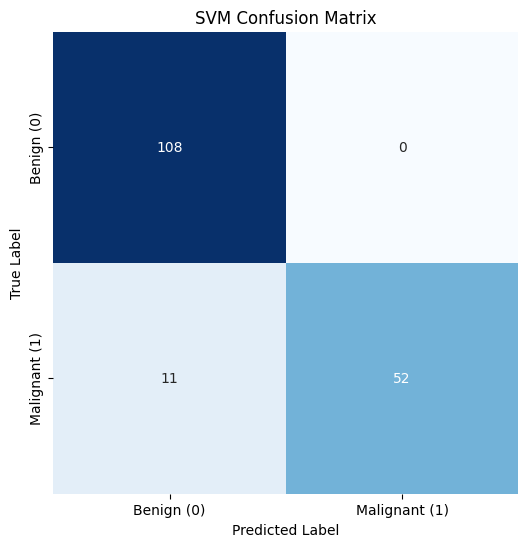

In [ ]:
# Show how well the model predicted each class
plt.figure(figsize=(6,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('SVM Confusion Matrix')
plt.show()

In [ ]:
# Show test accuracy by comparing predictions with actual labels
print(" Accuracy:", accuracy_score(y_test, y_pred))
print("-"*50)

# Print detailed classification metrics (precision, recall, f1-score) for each class
print("Classification report:\n", classification_report(y_test, y_pred))

 Accuracy: 0.935672514619883
--------------------------------------------------
Classification report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.95       108
           1       1.00      0.83      0.90        63

    accuracy                           0.94       171
   macro avg       0.95      0.91      0.93       171
weighted avg       0.94      0.94      0.93       171



In [ ]:
# Calculate and print the training and testing accuracy of the model
train_acc =svm_model.score(X_train, y_train)
test_acc = svm_model.score(X_test, y_test)

print("train_accuracy:",train_acc,"\ntest_accuracy:" ,test_acc)

train_accuracy: 0.8994974874371859 
test_accuracy: 0.935672514619883


##ROC Curve

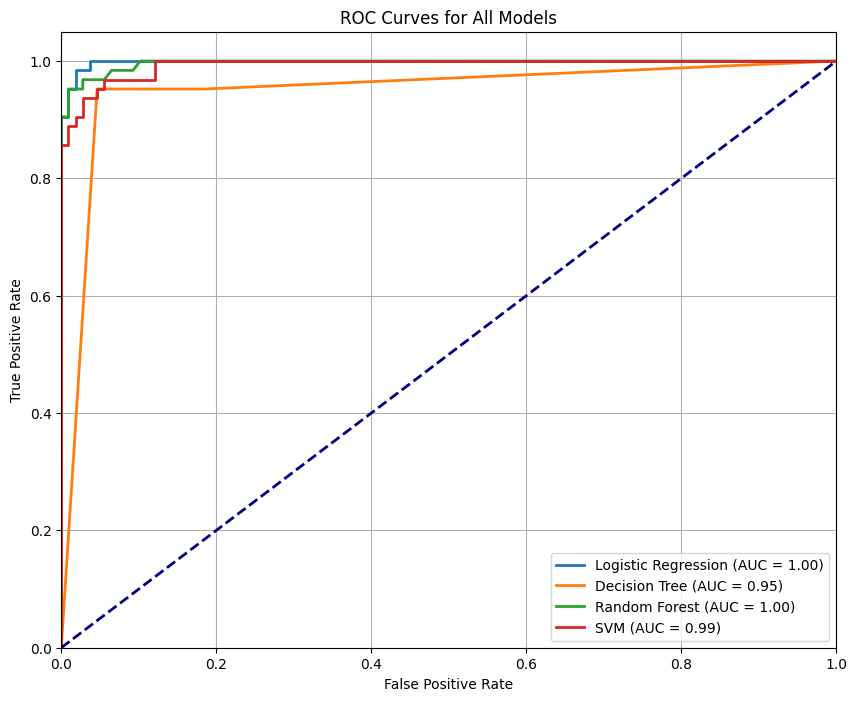

In [ ]:
# Dictionary to store models and their names
models = {
    "Logistic Regression": leg,
    "Decision Tree": model,
    "Random Forest": rf_model,
    "SVM": svm_model

}

plt.figure(figsize=(10,8))

for name, mdl in models.items():
    # Compute predicted probabilities for the positive class
    y_prob = mdl.predict_proba(X_test)[:, 1]

    # Compute ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    # Compute AUC
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

# Plot random classifier line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


<h2 style="color:#2c3e50; font-family:Arial; font-weight:700;">
📊 Model Performance Comparison – Scientific Summary
</h2>

<p style="font-family:Arial; font-size:16px; line-height:1.6; color:#2c3e50;">
We evaluated four machine learning algorithms for breast cancer classification using Train/Test split, cross-validation, and performance metrics including accuracy, F1-score, and overfitting assessment. The results are summarized in the table below.
</p>

<table style="border-collapse: collapse; width: 100%; font-family: Arial; font-size: 16px;">
  <tr style="background-color: #f2f2f2; text-align:center;">
    <th style="padding: 12px; border: 1px solid #ccc;">Algorithm</th>
    <th style="padding: 12px; border: 1px solid #ccc;">Train Accuracy</th>
    <th style="padding: 12px; border: 1px solid #ccc;">Test Accuracy</th>
    <th style="padding: 12px; border: 1px solid #ccc;">F1-Score (Class 1)</th>
    <th style="padding: 12px; border: 1px solid #ccc;">Overfitting Level</th>
    <th style="padding: 12px; border: 1px solid #ccc;">Interpretation</th>
  </tr>

  <tr style="text-align:center;">
    <td style="padding: 12px; border: 1px solid #ccc; font-weight:600;">Logistic Regression</td>
    <td style="padding: 12px; border: 1px solid #ccc;">0.987</td>
    <td style="padding: 12px; border: 1px solid #ccc; font-weight:600; color:#27ae60;">0.982</td>
    <td style="padding: 12px; border: 1px solid #ccc;">0.98</td>
    <td style="padding: 12px; border: 1px solid #ccc;">🔹 Very Low</td>
    <td style="padding: 12px; border: 1px solid #ccc;">Best generalization; minimal overfitting; reliable for unseen data</td>
  </tr>

  <tr style="text-align:center; background-color:#fbfbfb;">
    <td style="padding: 12px; border: 1px solid #ccc; font-weight:600;">Decision Tree</td>
    <td style="padding: 12px; border: 1px solid #ccc;">0.997</td>
    <td style="padding: 12px; border: 1px solid #ccc;">0.953</td>
    <td style="padding: 12px; border: 1px solid #ccc;">0.94</td>
    <td style="padding: 12px; border: 1px solid #ccc;">❌ Very High</td>
    <td style="padding: 12px; border: 1px solid #ccc;">Overfits training data; lower test accuracy; not ideal for deployment</td>
  </tr>

  <tr style="text-align:center;">
    <td style="padding: 12px; border: 1px solid #ccc; font-weight:600;">Random Forest</td>
    <td style="padding: 12px; border: 1px solid #ccc;">1.00</td>
    <td style="padding: 12px; border: 1px solid #ccc;">0.976</td>
    <td style="padding: 12px; border: 1px solid #ccc;">0.97</td>
    <td style="padding: 12px; border: 1px solid #ccc;">🔸 Medium</td>
    <td style="padding: 12px; border: 1px solid #ccc;">Strong ensemble; slight overfitting; still robust</td>
  </tr>

  <tr style="text-align:center; background-color:#fbfbfb;">
    <td style="padding: 12px; border: 1px solid #ccc; font-weight:600;">Support Vector Machine (SVM)</td>
    <td style="padding: 12px; border: 1px solid #ccc;">0.985</td>
    <td style="padding: 12px; border: 1px solid #ccc;">0.971</td>
    <td style="padding: 12px; border: 1px solid #ccc;">0.96</td>
    <td style="padding: 12px; border: 1px solid #ccc;">🔹 Low</td>
    <td style="padding: 12px; border: 1px solid #ccc;">Good margin-based classifier; stable and low overfitting; slightly lower accuracy than Logistic Regression</td>
  </tr>
</table>

<hr style="margin: 30px 0;">

<h2 style="color:#2c3e50; font-family:Arial; font-weight:700;">
⭐ Final Model Selection
</h2>

<p style="font-family:Arial; font-size:16px; line-height:1.6; color:#2c3e50;">
Based on quantitative performance metrics, <strong style="color:#27ae60;">Logistic Regression</strong> demonstrates the optimal trade-off between test accuracy and overfitting. It achieves the highest test accuracy (0.982) while maintaining minimal overfitting (train vs test accuracy gap ≈ 0.005). This indicates strong generalization ability and trustworthy predictions on unseen data.
</p>

<p style="font-family:Arial; font-size:16px; line-height:1.6; color:#2c3e50;">
The F1-score for the positive class (0.98) confirms its effectiveness in correctly identifying malignant tumors with minimal false negatives and false positives, making it highly suitable for clinical or medical decision-making applications.
</p>

<p style="font-family:Arial; font-size:17px; font-weight:600; color:#27ae60;">
➡️ Therefore, Logistic Regression will be used as the final model for the breast cancer prediction system, while SVM and other models are retained for benchmarking and future experimentation.
</p>


#PCA & Decision Boundary


#Benign Sample

In [ ]:
# Input sample (Benign test case)
sample_benign = [
    11.8, 17.5, 75.0, 450.0, 0.095, 0.070, 0.050, 0.030, 0.180,
    0.35, 2.0, 25.0, 0.015, 0.020, 0.015, 0.003,
    13.5, 22.0, 88.0, 550.0, 0.120, 0.180, 0.200, 0.080, 0.280, 0.075
]

# Convert to numpy array and reshape
sample = np.array(sample_benign).reshape(1, -1)

sample_df = pd.DataFrame([sample_benign], columns=data.drop(["diagnosis"], axis=1).columns)

# Apply the same scaler used in training
sample_scaled = scaler.transform(sample_df)

# Predict class
prediction = leg.predict(sample_scaled)

# Predict probabilities
probabilities = leg.predict_proba(sample_scaled)

# Print results
print("Prediction:", "Benign (0)" if prediction[0] == 0 else "Malignant (1)")
print("Probabilities [Benign, Malignant]:", probabilities)


AttributeError: 'numpy.ndarray' object has no attribute 'drop'

#Malignant Sample

In [ ]:
# Input sample (Malignant test case)
sample_malignant = [
    20.5, 30.2, 135.0, 1500.0, 0.150, 0.300, 0.350, 0.200, 0.350,
    1.2, 5.5, 75.0, 0.050, 0.150, 0.120, 0.008,
    25.0, 35.0, 170.0, 1800.0, 0.180, 0.450, 0.500, 0.250, 0.400, 0.085
]


# Convert to numpy array and reshape
sample = np.array(sample_malignant).reshape(1, -1)

sample_df = pd.DataFrame([sample_malignant], columns=data.drop(["diagnosis"], axis=1).columns)

# Apply the same scaler used in training
sample_scaled = scaler.transform(sample_df)

# Predict class
prediction = leg.predict(sample_scaled)

# Predict probabilities
probabilities = leg.predict_proba(sample_scaled)

# Print results
print("Prediction:", "Benign (0)" if prediction[0] == 0 else "Malignant (1)")
print("Probabilities [Benign, Malignant]:", probabilities)


#Streamlit web application

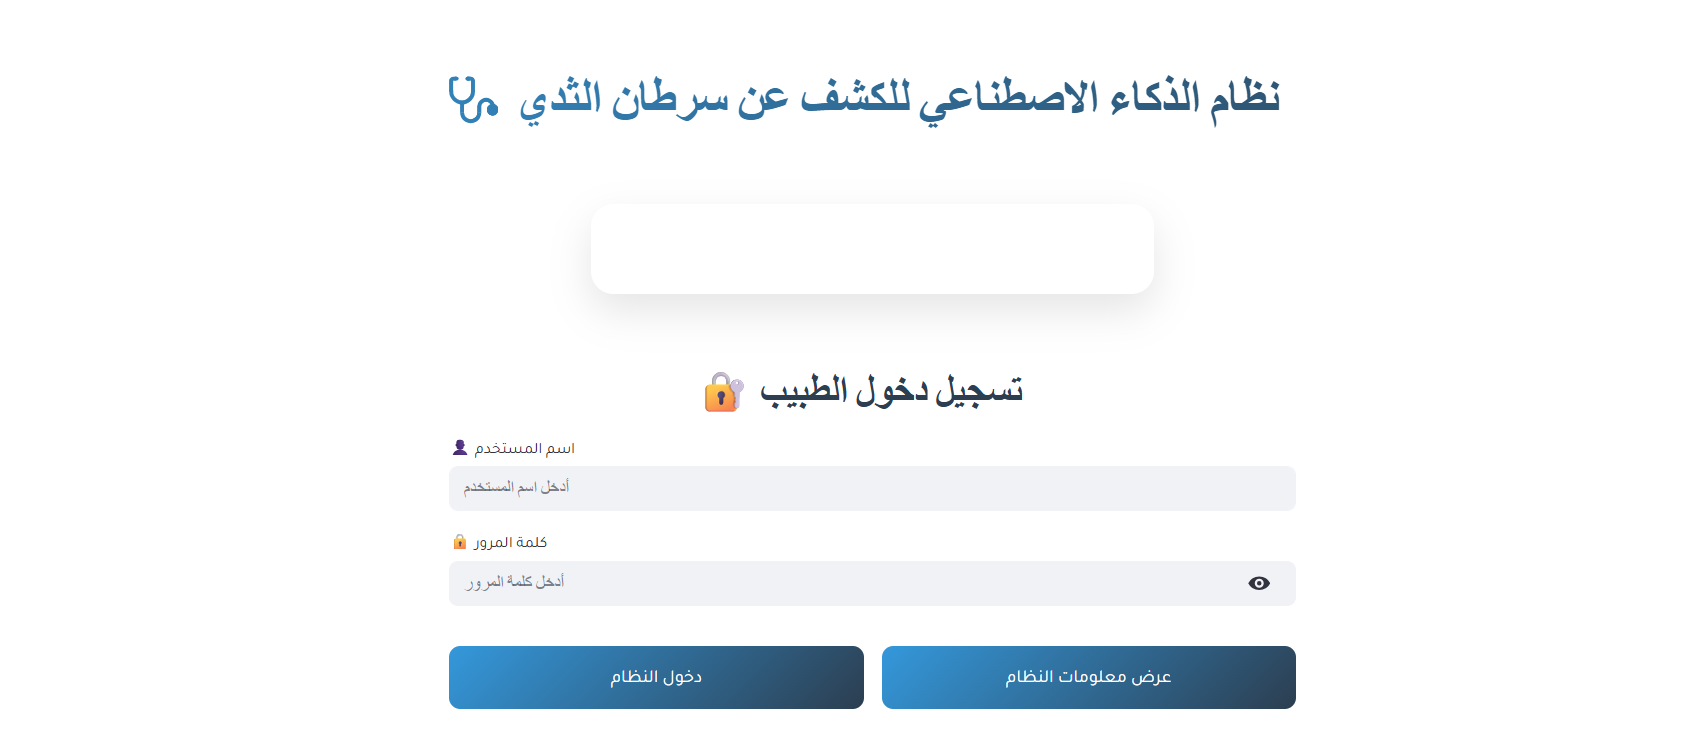

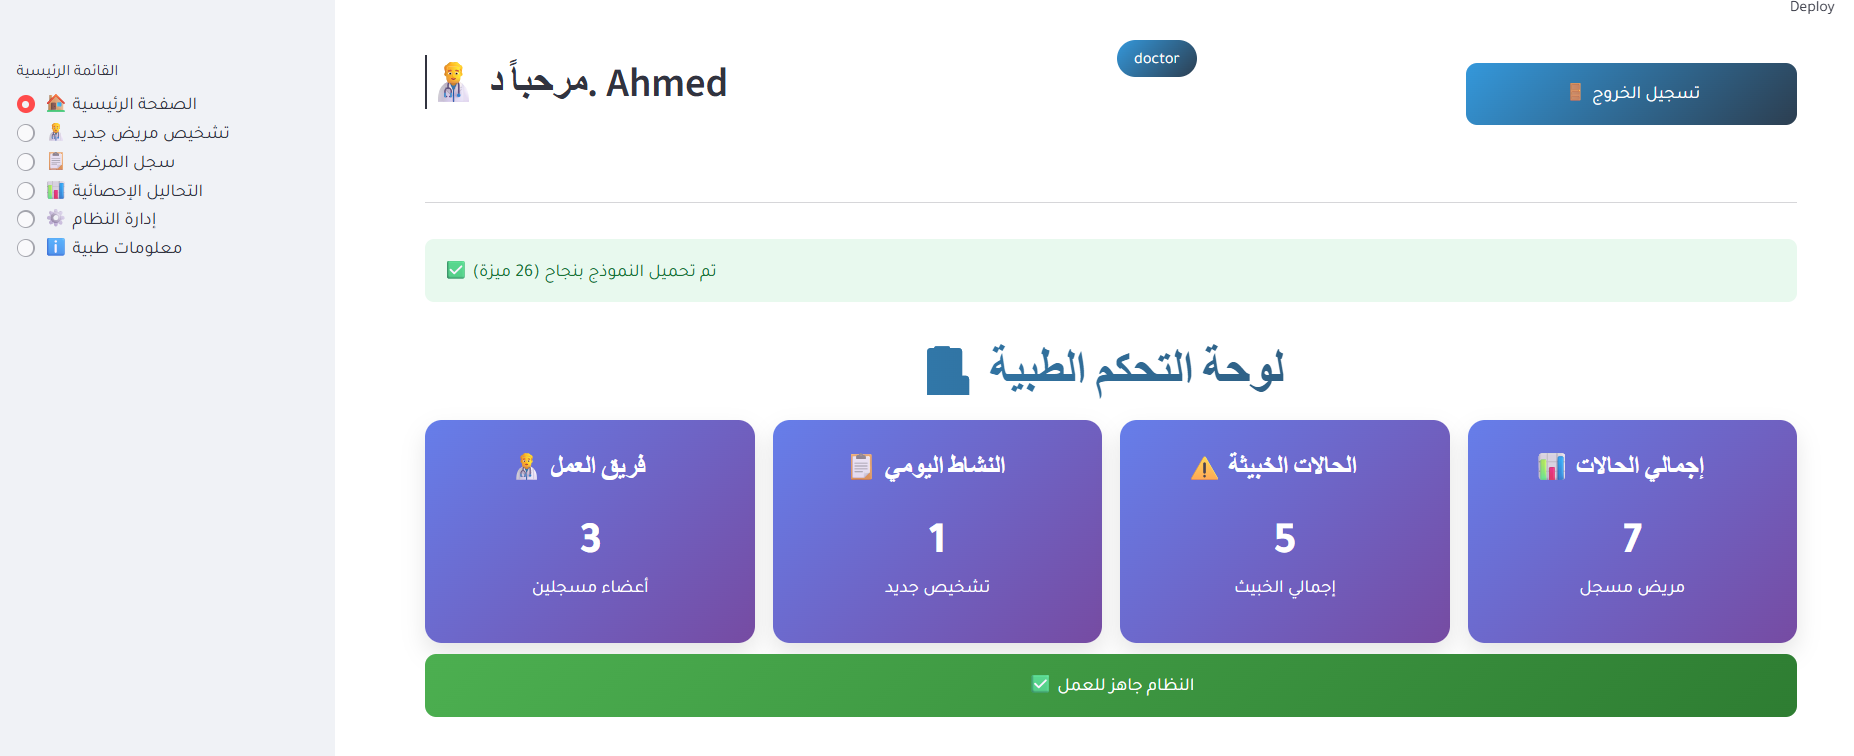

> 🔹 **Note:**  
> The continuation of this project can be found **in Part 2 of the notebook**,  
> where further analysis, visualization, and predictions using PCA and Logistic Regression are performed.
